# Chapter 11: Challenges and Future Directions
## Practical: LIME, PINN, and Few-Shot Learning

## 1. LIME for Model Interpretability

Test accuracy: 0.867

LIME Explanation Concept:
LIME approximates the model locally with an interpretable model
to explain individual predictions.
For an image, it highlights the pixels that most support the prediction.


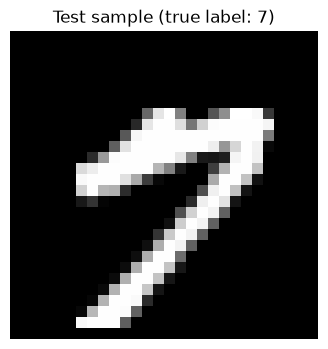

Predicted label: 7


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Load MNIST subset
try:
    X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='pandas')
except:
    # Fallback to synthetic data if fetch_openml fails
    print("Using synthetic data (MNIST not available)")
    np.random.seed(42)
    X = np.random.randn(1000, 784)
    y = np.random.randint(0, 10, 1000)

X = X[:1000].astype(np.float32) / 255.0
y = y[:1000].astype(np.int32)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Random Forest classifier
clf = RandomForestClassifier(n_estimators=50, random_state=42)
clf.fit(X_train, y_train)
print(f"Test accuracy: {clf.score(X_test, y_test):.3f}")

# LIME is a separate package. For demonstration, we show the concept.
# In practice, run: from lime.lime_image import LimeImageExplainer
# Then use: explainer = LimeImageExplainer()

print("\nLIME Explanation Concept:")
print("LIME approximates the model locally with an interpretable model")
print("to explain individual predictions.")
print("For an image, it highlights the pixels that most support the prediction.")

# Visualise a sample image
idx = 0
plt.figure(figsize=(4, 4))
plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
plt.title(f'Test sample (true label: {y_test[idx]})')
plt.axis('off')
plt.show()

print(f"Predicted label: {clf.predict(X_test[idx:idx+1])[0]}")

# 2. PINN for Burgers Equation (Conceptual)

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

class PINN_Burgers(nn.Module):
    def __init__(self, layers=[2, 20, 20, 20, 20, 1]):
        super().__init__()
        self.net = nn.Sequential()
        for i in range(len(layers)-2):
            self.net.append(nn.Linear(layers[i], layers[i+1]))
            self.net.append(nn.Tanh())
        self.net.append(nn.Linear(layers[-2], layers[-1]))

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        return self.net(inp)

    def loss(self, x, t, u, x_f, t_f, x_b, t_b, u_b):
        u_pred = self.forward(x, t)
        data_loss = nn.MSELoss()(u_pred, u)
        
        u_b_pred = self.forward(x_b, t_b)
        bc_loss = nn.MSELoss()(u_b_pred, u_b)
        
        u_pred_f = self.forward(x_f, t_f)
        u_x = torch.autograd.grad(u_pred_f, x_f, 
                                  grad_outputs=torch.ones_like(u_pred_f), 
                                  create_graph=True)[0]
        u_t = torch.autograd.grad(u_pred_f, t_f, 
                                  grad_outputs=torch.ones_like(u_pred_f), 
                                  create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x_f, 
                                   grad_outputs=torch.ones_like(u_x), 
                                   create_graph=True)[0]
        
        nu = 0.01 / np.pi
        pde_residual = u_t + u_pred_f * u_x - nu * u_xx
        pde_loss = torch.mean(pde_residual**2)
        
        return data_loss + bc_loss + pde_loss

print("PINN for Burgers Equation:")
print("This implements a Physics-Informed Neural Network that")
print("solves the Burgers equation by embedding the PDE residual")
print("directly into the loss function.")
print("\nKey components:")
print("1. Data loss (initial condition)")
print("2. Boundary condition loss")
print("3. PDE residual loss")

PINN for Burgers Equation:
This implements a Physics-Informed Neural Network that
solves the Burgers equation by embedding the PDE residual
directly into the loss function.

Key components:
1. Data loss (initial condition)
2. Boundary condition loss
3. PDE residual loss


# 3. Few-Shot Classification with Prototypical Networks

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PrototypicalNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, embedding_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embedding_dim)
        )

    def forward(self, support_set, query_set):
        # support_set: (n_way, n_support, input_dim)
        # query_set: (n_way, n_query, input_dim)
        support_emb = self.encoder(support_set)  # (n_way, n_support, emb_dim)
        query_emb = self.encoder(query_set)      # (n_way, n_query, emb_dim)
        prototypes = support_emb.mean(dim=1)     # (n_way, emb_dim)
        distances = torch.cdist(query_emb, prototypes)  # (n_way, n_query, n_way)
        logits = -distances
        return logits

# Demonstrate with synthetic data
input_dim = 10
hidden_dim = 20
embedding_dim = 5
n_way = 3
n_support = 5
n_query = 3

support_set = torch.randn(n_way, n_support, input_dim)
query_set = torch.randn(n_way, n_query, input_dim)

model = PrototypicalNetwork(input_dim, hidden_dim, embedding_dim)
logits = model(support_set, query_set)

print(f"Support set: {support_set.shape}")
print(f"Query set: {query_set.shape}")
print(f"Logits: {logits.shape}")

## Observations

- **LIME**: Provides local interpretability by approximating the model with a simpler one.
- **PINN**: Embed physics directly into the loss function for physically consistent predictions.
- **Few-shot learning**: Learn from very few examples using metric learning in embedding space.
- These techniques address key challenges: interpretability, data scarcity, and physical consistency.